# Tech Stock Screener v2 — Momentum + Skeptic Filter

Combines two independent scoring layers to cut through analyst bias:

| Layer | Score | What it measures |
|---|---|---|
| **Momentum** | 0–10 | RSI, MACD, SMA 20/50/200, volume surge, 1m/3m returns |
| **Skeptic** | 0–9 | EPS revisions, short interest, insider activity, PT cuts, analyst skew |
| **Combo** | avg | A stock must pass **both** filters independently |

> **Verdict**: `Pass` = both ≥ 6 · `Watch` = one weak · `Fail` = fails skeptic

---


## 1. Install dependencies

In [1]:
import sys

# ── Python version gate ──────────────────────────────────────────
major, minor = sys.version_info[:2]
print(f"Python {major}.{minor}  |  {sys.executable}")

if (major, minor) < (3, 10):
    print()
    print("❌ schwab-py requires Python 3.10+")
    print(f"   You are running Python {major}.{minor}")
    print()
    print("─" * 55)
    print("FIX — run these commands in your Terminal:")
    print("─" * 55)
    print()
    print("  # Option A: Homebrew (recommended)")
    print("  brew install python@3.11")
    print("  python3.11 -m venv .venv")
    print("  source .venv/bin/activate")
    print("  pip install schwab-py httpx pandas numpy \\")
    print("              requests matplotlib seaborn jupyter")
    print("  jupyter notebook")
    print()
    print("  # Option B: conda")
    print("  conda create -n screener python=3.11 -y")
    print("  conda activate screener")
    print("  pip install schwab-py httpx pandas numpy \\")
    print("              requests matplotlib seaborn jupyter")
    print("  jupyter notebook")
    print()
    print("Then reopen this notebook and switch the kernel to")
    print("your new Python 3.11 environment.")
    raise SystemExit("Upgrade Python to 3.10+ before continuing.")

# ── Install packages ─────────────────────────────────────────────
import subprocess

packages = [
    "schwab-py", "httpx", "pandas", "numpy",
    "requests", "matplotlib", "seaborn"
]

print(f"\nInstalling {len(packages)} packages...")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "--upgrade"] + packages,
    capture_output=True, text=True
)

if result.returncode == 0:
    print("✅ All dependencies installed successfully")
else:
    print("❌ pip failed. Run this in your terminal:")
    print(f"   {sys.executable} -m pip install " + " ".join(packages))
    print()
    print(result.stderr[-1000:])


Python 3.11  |  /opt/homebrew/opt/python@3.11/bin/python3.11

Installing 7 packages...
✅ All dependencies installed successfully


## 2. Imports & configuration

In [2]:
import os, sys, json, time, warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta
from dataclasses import dataclass, field
from typing import Optional
from IPython.display import display, HTML

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# ── Schwab credentials (set env vars or replace directly)
API_KEY    = os.getenv("SCHWAB_API_KEY",    "YOUR_APP_KEY")
APP_SECRET = os.getenv("SCHWAB_APP_SECRET", "YOUR_APP_SECRET")
TOKEN_PATH = os.getenv("SCHWAB_TOKEN_PATH", "token.json")

# ── Watchlist — customize freely
WATCHLIST = [
    "NVDA", "MSFT", "AAPL", "META", "GOOGL", "AMZN",
    "AMD",  "AVGO", "TSM",  "ORCL", "CRM",  "ADBE",
    "QCOM", "MU",   "INTC", "SNOW", "PLTR", "NET",
    "SMCI", "ARM",
]

# ── Thresholds
RSI_OVERBOUGHT      = 70
MIN_VOLUME_RATIO    = 1.5
ANALYST_SKEW_LIMIT  = 85    # % buy ratings above this = inflated
PT_CUT_WARNING      = 5     # % PT cut even with Buy rating = warning

DEMO_MODE = (API_KEY == "YOUR_APP_KEY")   # auto-switches to demo if no credentials
print(f"Mode: {'DEMO (synthetic data)' if DEMO_MODE else 'LIVE (Schwab API)'}")
print(f"Watchlist: {len(WATCHLIST)} stocks")

Mode: DEMO (synthetic data)
Watchlist: 20 stocks


## 3. Data structure

In [3]:
@dataclass
class ScreenResult:
    symbol: str
    price: float
    # Momentum
    mscore: int
    rsi_14: float
    macd_signal: str
    above_sma20: bool
    above_sma50: bool
    above_sma200: bool
    volume_ratio: float
    ret_1w: float
    ret_1m: float
    ret_3m: float
    # Skeptic
    sscore: int
    eps_revisions: int
    short_interest: float
    insider_action: str
    pt_cut_pct: float
    analyst_buy_pct: float
    # Combined
    combo: float
    verdict: str
    timestamp: str = field(default_factory=lambda: datetime.now().strftime("%Y-%m-%d %H:%M"))

print("✅ ScreenResult dataclass defined")

✅ ScreenResult dataclass defined


## 4. Momentum indicators

Core technical signals — RSI, MACD, SMA, volume, and returns.

In [4]:
def calc_rsi(closes: pd.Series, period: int = 14) -> float:
    delta    = closes.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period).mean()
    rs       = avg_gain / avg_loss.replace(0, np.nan)
    rsi      = 100 - (100 / (1 + rs))
    return round(float(rsi.iloc[-1]), 2)


def calc_macd(closes: pd.Series) -> str:
    ema12  = closes.ewm(span=12, adjust=False).mean()
    ema26  = closes.ewm(span=26, adjust=False).mean()
    macd   = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    hist   = macd - signal
    if float(macd.iloc[-1]) > float(signal.iloc[-1]) and float(hist.iloc[-1]) > float(hist.iloc[-2]):
        return "Bullish"
    elif float(macd.iloc[-1]) < float(signal.iloc[-1]) and float(hist.iloc[-1]) < float(hist.iloc[-2]):
        return "Bearish"
    return "Neutral"


def calc_sma(closes: pd.Series, window: int) -> float:
    return round(float(closes.rolling(window).mean().iloc[-1]), 4)


def calc_volume_ratio(volumes: pd.Series, window: int = 20) -> float:
    avg = volumes.iloc[-window-1:-1].mean()
    return round(float(volumes.iloc[-1]) / avg, 2) if avg > 0 else 0.0


def calc_return(closes: pd.Series, days: int) -> float:
    if len(closes) < days + 1:
        return 0.0
    return round(float(closes.iloc[-1] / closes.iloc[-days] - 1), 4)


def momentum_score(rsi, macd, above20, above50, above200, vol_ratio, ret_1m, ret_3m) -> int:
    s = 0
    if 45 <= rsi <= 65:   s += 2
    elif 40 <= rsi < 45 or 65 < rsi <= 70: s += 1
    if macd == "Bullish": s += 2
    elif macd == "Neutral": s += 1
    if above20:  s += 1
    if above50:  s += 1
    if above200: s += 1
    if vol_ratio >= MIN_VOLUME_RATIO: s += 1
    if ret_1m >= 0.05: s += 1
    if ret_3m >= 0.10: s += 1
    return min(s, 10)

print("✅ Momentum indicators defined")

✅ Momentum indicators defined


## 5. Skeptic data sources

These pull **hard data** that is harder to game than analyst ratings:

- **FINRA** — short interest % of float (free API)
- **SEC EDGAR** — insider Form 4 transactions (free API)
- **Schwab API** — EPS estimate revisions + analyst consensus


In [5]:
def get_short_interest_finra(symbol: str) -> float:
    """Short interest % of float from FINRA free API."""
    try:
        url = (
            f"https://api.finra.org/data/group/otcMarket/name/regShoDaily"
            f"?limit=1&compareFilters=symbolCode:equalsTo:{symbol}"
        )
        resp = requests.get(url, timeout=8)
        data = resp.json()
        if data and isinstance(data, list):
            return float(data[0].get("shortInterestPercent", 0))
    except Exception:
        pass
    return 0.0


def get_insider_activity_edgar(symbol: str) -> str:
    """Net insider Form 4 activity from SEC EDGAR — 'buy', 'sell', or 'none'."""
    try:
        start = (datetime.now() - timedelta(days=90)).strftime('%Y-%m-%d')
        url   = f"https://efts.sec.gov/LATEST/search-index?q=%22{symbol}%22&dateRange=custom&startdt={start}&forms=4"
        resp  = requests.get(url, headers={"User-Agent": "TechScreener contact@example.com"}, timeout=8)
        hits  = resp.json().get("hits", {}).get("hits", [])
        buys = sells = 0
        for h in hits[:20]:
            src = h.get("_source", {})
            if src.get("form_type") != "4":
                continue
            entity = src.get("entity_name", "").upper()
            if "PURCHASE" in entity or " P " in entity: buys += 1
            elif "SALE" in entity or " S " in entity:   sells += 1
        if buys > sells:  return "buy"
        if sells > buys:  return "sell"
    except Exception:
        pass
    return "none"


def get_analyst_data_schwab(client, symbol: str) -> dict:
    """Analyst consensus from Schwab market data API."""
    try:
        resp        = client.get_quote(symbol)
        fundamental = resp.json().get(symbol, {}).get("fundamental", {})
        return {
            "buy_pct":    fundamental.get("consensusBuyPercent", 75),
            "pt_current": fundamental.get("priceTargetMean", 0),
            "pt_30d_ago": fundamental.get("priceTargetMean30dAgo", 0),
        }
    except Exception:
        return {"buy_pct": 75, "pt_current": 0, "pt_30d_ago": 0}


def get_eps_revisions_schwab(client, symbol: str) -> int:
    """Net EPS estimate revisions (upgrades minus downgrades) over last 90 days."""
    try:
        data  = client.get_quote(symbol).json().get(symbol, {}).get("fundamental", {})
        ups   = data.get("epsRevisionsUpLast90Days", 0) or 0
        downs = data.get("epsRevisionsDownLast90Days", 0) or 0
        return int(ups) - int(downs)
    except Exception:
        return 0


def skeptic_score(eps_rev, short_int, insider, pt_cut_pct, buy_pct) -> int:
    """
    Score 0–9. Higher = hard data confirms bullish thesis.
    Analyst buy% >= 85 gives a -1 penalty (too skewed to trust).
    """
    s = 0
    if eps_rev >= 2:   s += 3
    elif eps_rev == 1: s += 2
    elif eps_rev == 0: s += 1

    if short_int <= 1.5:   s += 2
    elif short_int <= 3.0: s += 1

    if insider == "buy":    s += 2
    elif insider == "none": s += 1

    if pt_cut_pct == 0:             s += 2
    elif pt_cut_pct <= PT_CUT_WARNING: s += 1

    if buy_pct >= ANALYST_SKEW_LIMIT: s -= 1   # penalty for inflated coverage

    return max(0, min(s, 9))


def combo_verdict(mscore, sscore) -> tuple:
    combo = round((mscore + sscore) / 2, 1)
    if mscore >= 6 and sscore >= 6: verdict = "Pass"
    elif mscore >= 5 and sscore >= 4: verdict = "Watch"
    else: verdict = "Fail"
    return combo, verdict

print("✅ Skeptic data functions defined")

✅ Skeptic data functions defined


## 6. Demo mode — synthetic price data

Run without Schwab credentials. Generates realistic OHLCV series per symbol.

In [6]:
DEMO_SKEPTIC = {
    "NVDA": dict(eps_rev=2,  si=1.2, ins="buy",  ptcut=0,   buypct=92),
    "PLTR": dict(eps_rev=2,  si=2.1, ins="buy",  ptcut=3,   buypct=55),
    "META": dict(eps_rev=1,  si=0.9, ins="none", ptcut=0,   buypct=88),
    "AMD":  dict(eps_rev=0,  si=3.8, ins="none", ptcut=8,   buypct=78),
    "ARM":  dict(eps_rev=1,  si=4.2, ins="none", ptcut=5,   buypct=62),
    "MSFT": dict(eps_rev=1,  si=0.7, ins="buy",  ptcut=0,   buypct=95),
    "AVGO": dict(eps_rev=2,  si=1.1, ins="none", ptcut=0,   buypct=91),
    "GOOGL":dict(eps_rev=0,  si=1.5, ins="none", ptcut=4,   buypct=85),
    "NET":  dict(eps_rev=-1, si=5.1, ins="sell", ptcut=12,  buypct=58),
    "QCOM": dict(eps_rev=-1, si=3.2, ins="none", ptcut=10,  buypct=60),
    "SNOW": dict(eps_rev=-2, si=6.8, ins="sell", ptcut=18,  buypct=52),
    "INTC": dict(eps_rev=-3, si=4.5, ins="sell", ptcut=22,  buypct=30),
    "SMCI": dict(eps_rev=-1, si=9.2, ins="sell", ptcut=15,  buypct=40),
    "ADBE": dict(eps_rev=-1, si=2.1, ins="none", ptcut=8,   buypct=72),
    "ORCL": dict(eps_rev=1,  si=1.0, ins="buy",  ptcut=0,   buypct=80),
    "TSM":  dict(eps_rev=0,  si=1.3, ins="none", ptcut=2,   buypct=90),
    "MU":   dict(eps_rev=-2, si=3.9, ins="none", ptcut=14,  buypct=65),
    "CRM":  dict(eps_rev=0,  si=1.8, ins="none", ptcut=3,   buypct=76),
    "AMZN": dict(eps_rev=1,  si=0.8, ins="none", ptcut=0,   buypct=94),
}


def generate_demo_prices(symbol: str) -> pd.DataFrame:
    np.random.seed(hash(symbol) % (2**31))
    n      = 250
    base   = np.random.uniform(50, 800)
    drift  = np.random.uniform(-0.001, 0.003)
    vol    = np.random.uniform(0.01, 0.025)
    closes = [base]
    for _ in range(n - 1):
        closes.append(closes[-1] * (1 + drift + np.random.normal(0, vol)))
    closes  = np.array(closes)
    volumes = np.random.randint(5_000_000, 50_000_000, n).astype(float)
    volumes[np.random.choice(n, 5, replace=False)] *= np.random.uniform(2, 4, 5)
    dates = pd.date_range(end=datetime.today(), periods=n, freq="B")
    return pd.DataFrame({"date":dates,"open":closes*.99,"high":closes*1.01,
                         "low":closes*.98,"close":closes,"volume":volumes})

print("✅ Demo data generators ready")

✅ Demo data generators ready


## 7. Run the screener

Automatically uses **Demo mode** if no Schwab credentials are set, or **Live mode** if `SCHWAB_API_KEY` is configured.

In [7]:
def run_screener(symbols=WATCHLIST) -> pd.DataFrame:
    results = []

    if not DEMO_MODE:
        from schwab.auth import easy_client
        from schwab.client import Client
        client = easy_client(api_key=API_KEY, app_secret=APP_SECRET,
                             callback_url="https://127.0.0.1", token_path=TOKEN_PATH)

    for sym in symbols:
        try:
            if DEMO_MODE:
                df      = generate_demo_prices(sym)
                sk      = DEMO_SKEPTIC.get(sym, dict(eps_rev=0,si=2.0,ins="none",ptcut=5,buypct=70))
                eps_rev = sk["eps_rev"]; short_int = sk["si"]
                insider = sk["ins"];     pt_cut    = sk["ptcut"]
                buy_pct = sk["buypct"]
            else:
                resp = client.get_price_history(
                    sym,
                    period_type=Client.PriceHistory.PeriodType.YEAR,
                    period=Client.PriceHistory.Period.ONE_YEAR,
                    frequency_type=Client.PriceHistory.FrequencyType.DAILY,
                    frequency=Client.PriceHistory.Frequency.EVERY_MINUTE,
                )
                raw = resp.json()
                if "candles" not in raw or not raw["candles"]:
                    raise ValueError("No candle data")
                df = pd.DataFrame(raw["candles"])
                df["date"] = pd.to_datetime(df["datetime"], unit="ms")
                df = df.sort_values("date").reset_index(drop=True)
                eps_rev   = get_eps_revisions_schwab(client, sym)
                short_int = get_short_interest_finra(sym)
                insider   = get_insider_activity_edgar(sym)
                analyst   = get_analyst_data_schwab(client, sym)
                buy_pct   = analyst["buy_pct"]
                pt_now    = analyst["pt_current"]
                pt_prev   = analyst["pt_30d_ago"]
                pt_cut    = max(0, round((pt_prev-pt_now)/pt_prev*100, 1)) if pt_prev > 0 else 0
                time.sleep(0.3)

            closes  = df["close"]
            volumes = df["volume"]
            price   = round(float(closes.iloc[-1]), 2)
            rsi     = calc_rsi(closes)
            macd    = calc_macd(closes)
            sma20   = calc_sma(closes, 20)
            sma50   = calc_sma(closes, 50)
            sma200  = calc_sma(closes, 200)
            vol_r   = calc_volume_ratio(volumes)
            r1w     = calc_return(closes, 5)
            r1m     = calc_return(closes, 21)
            r3m     = calc_return(closes, 63)
            ms      = momentum_score(rsi, macd, price>sma20, price>sma50, price>sma200, vol_r, r1m, r3m)
            ss      = skeptic_score(eps_rev, short_int, insider, pt_cut, buy_pct)
            combo, verdict = combo_verdict(ms, ss)

            results.append(ScreenResult(
                symbol=sym, price=price,
                mscore=ms, rsi_14=rsi, macd_signal=macd,
                above_sma20=price>sma20, above_sma50=price>sma50, above_sma200=price>sma200,
                volume_ratio=vol_r, ret_1w=r1w, ret_1m=r1m, ret_3m=r3m,
                sscore=ss, eps_revisions=eps_rev, short_interest=short_int,
                insider_action=insider, pt_cut_pct=pt_cut, analyst_buy_pct=buy_pct,
                combo=combo, verdict=verdict,
            ))
            print(f"  {sym:6s}  M={ms:2d}  S={ss:2d}  Combo={combo:.1f}  [{verdict}]")
        except Exception as e:
            print(f"  {sym}: ERROR — {e}")

    df_out = pd.DataFrame([vars(r) for r in results])
    df_out = df_out.sort_values("combo", ascending=False).reset_index(drop=True)
    return df_out


# ── RUN ──
print(f"Scanning {len(WATCHLIST)} stocks...\n")
df = run_screener()
print(f"\n✅ Done — {len(df)} stocks screened")

Scanning 20 stocks...

  NVDA    M= 5  S= 8  Combo=6.5  [Watch]
  MSFT    M= 6  S= 7  Combo=6.5  [Pass]
  AAPL    M= 4  S= 4  Combo=4.0  [Fail]
  META    M= 7  S= 6  Combo=6.5  [Pass]
  GOOGL   M= 7  S= 4  Combo=5.5  [Watch]
  AMZN    M= 0  S= 6  Combo=3.0  [Fail]
  AMD     M= 7  S= 2  Combo=4.5  [Fail]
  AVGO    M= 0  S= 7  Combo=3.5  [Fail]
  TSM     M= 7  S= 4  Combo=5.5  [Watch]
  ORCL    M= 7  S= 8  Combo=7.5  [Pass]
  CRM     M= 1  S= 4  Combo=2.5  [Fail]
  ADBE    M= 1  S= 2  Combo=1.5  [Fail]
  QCOM    M= 2  S= 1  Combo=1.5  [Fail]
  MU      M= 6  S= 1  Combo=3.5  [Fail]
  INTC    M= 6  S= 0  Combo=3.0  [Fail]
  SNOW    M= 8  S= 0  Combo=4.0  [Fail]
  PLTR    M= 2  S= 7  Combo=4.5  [Fail]
  NET     M= 7  S= 0  Combo=3.5  [Fail]
  SMCI    M= 4  S= 0  Combo=2.0  [Fail]
  ARM     M= 3  S= 4  Combo=3.5  [Fail]

✅ Done — 20 stocks screened


## 8. Results table

In [9]:
def style_verdict(val):
    colors = {"Pass": "background:#d4edda;color:#155724",
              "Watch":"background:#fff3cd;color:#856404",
              "Fail": "background:#f8d7da;color:#721c24"}
    return colors.get(val, "")

def style_score(val):
    if val >= 7: return "color:#155724;font-weight:bold"
    if val >= 5: return "color:#856404;font-weight:bold"
    return "color:#721c24"

display_cols = ["symbol","price","mscore","sscore","combo","verdict",
                "eps_revisions","short_interest","insider_action",
                "pt_cut_pct","analyst_buy_pct","ret_1m","ret_3m"]

df_display = df[display_cols].copy()
df_display["ret_1m"] = (df_display["ret_1m"] * 100).round(2).astype(str) + "%"
df_display["ret_3m"] = (df_display["ret_3m"] * 100).round(2).astype(str) + "%"

styled = (df_display.style
    .map(style_verdict, subset=["verdict"])
    .map(style_score,   subset=["combo"])
    .format({"price": "${:.2f}", "short_interest": "{:.1f}%",
             "analyst_buy_pct": "{:.0f}%", "pt_cut_pct": "{:.1f}%"})
    .set_caption(f"Screener results — {datetime.now().strftime('%Y-%m-%d %H:%M')} · {'DEMO' if DEMO_MODE else 'LIVE'}")
    .set_table_styles([{"selector":"th","props":[("background","#2c3e50"),
                                                  ("color","white"),("padding","6px 10px")]}])
)
display(styled)

,symbol,price,mscore,sscore,combo,verdict,eps_revisions,short_interest,insider_action,pt_cut_pct,analyst_buy_pct,ret_1m,ret_3m
0,ORCL,$219.39,7,8,7.500000,Pass,1,1.0%,buy,0.0%,80%,11.74%,6.42%
1,NVDA,$919.42,5,8,6.500000,Watch,2,1.2%,buy,0.0%,92%,-4.17%,5.81%
2,META,$1017.98,7,6,6.500000,Pass,1,0.9%,none,0.0%,88%,0.07%,23.8%
3,MSFT,$738.86,6,7,6.500000,Pass,1,0.7%,buy,0.0%,95%,14.05%,22.38%
4,GOOGL,$649.69,7,4,5.500000,Watch,0,1.5%,none,4.0%,85%,8.49%,3.27%
5,TSM,$468.28,7,4,5.500000,Watch,0,1.3%,none,2.0%,90%,13.28%,28.87%
6,AMD,$965.67,7,2,4.500000,Fail,0,3.8%,none,8.0%,78%,5.54%,30.44%
7,PLTR,$838.04,2,7,4.500000,Fail,2,2.1%,buy,3.0%,55%,1.99%,3.08%
8,AAPL,$565.08,4,4,4.000000,Fail,0,2.0%,none,5.0%,70%,4.99%,-6.54%
9,SNOW,$772.27,8,0,4.000000,Fail,-2,6.8%,sell,18.0%,52%,8.58%,28.68%


## 9. Summary — Pass / Watch / Fail

In [10]:
for verdict_label in ["Pass", "Watch", "Fail"]:
    subset = df[df["verdict"] == verdict_label][["symbol","combo","mscore","sscore","ret_1m","ret_3m"]].copy()
    subset["ret_1m"] = (subset["ret_1m"]*100).round(2).astype(str)+"%"
    subset["ret_3m"] = (subset["ret_3m"]*100).round(2).astype(str)+"%"
    emoji = {"Pass":"✅","Watch":"⚠️","Fail":"❌"}[verdict_label]
    print(f"\n{emoji}  {verdict_label.upper()} ({len(subset)} stocks)")
    if subset.empty:
        print("   None")
    else:
        print(subset.to_string(index=False))


✅  PASS (3 stocks)
symbol  combo  mscore  sscore ret_1m ret_3m
  ORCL    7.5       7       8 11.74%  6.42%
  META    6.5       7       6  0.07%  23.8%
  MSFT    6.5       6       7 14.05% 22.38%

⚠️  WATCH (3 stocks)
symbol  combo  mscore  sscore ret_1m ret_3m
  NVDA    6.5       5       8 -4.17%  5.81%
 GOOGL    5.5       7       4  8.49%  3.27%
   TSM    5.5       7       4 13.28% 28.87%

❌  FAIL (14 stocks)
symbol  combo  mscore  sscore  ret_1m  ret_3m
   AMD    4.5       7       2   5.54%  30.44%
  PLTR    4.5       2       7   1.99%   3.08%
  AAPL    4.0       4       4   4.99%  -6.54%
  SNOW    4.0       8       0   8.58%  28.68%
    MU    3.5       6       1   8.72%   6.15%
   NET    3.5       7       0  15.37%  27.99%
   ARM    3.5       3       4  -8.27% -12.08%
  AVGO    3.5       0       7  -8.84% -14.32%
  INTC    3.0       6       0   2.92%  20.17%
  AMZN    3.0       0       6  -2.64%   0.85%
   CRM    2.5       1       4  -6.74%  -0.54%
  SMCI    2.0       4       0  -1

## 10. Visualizations

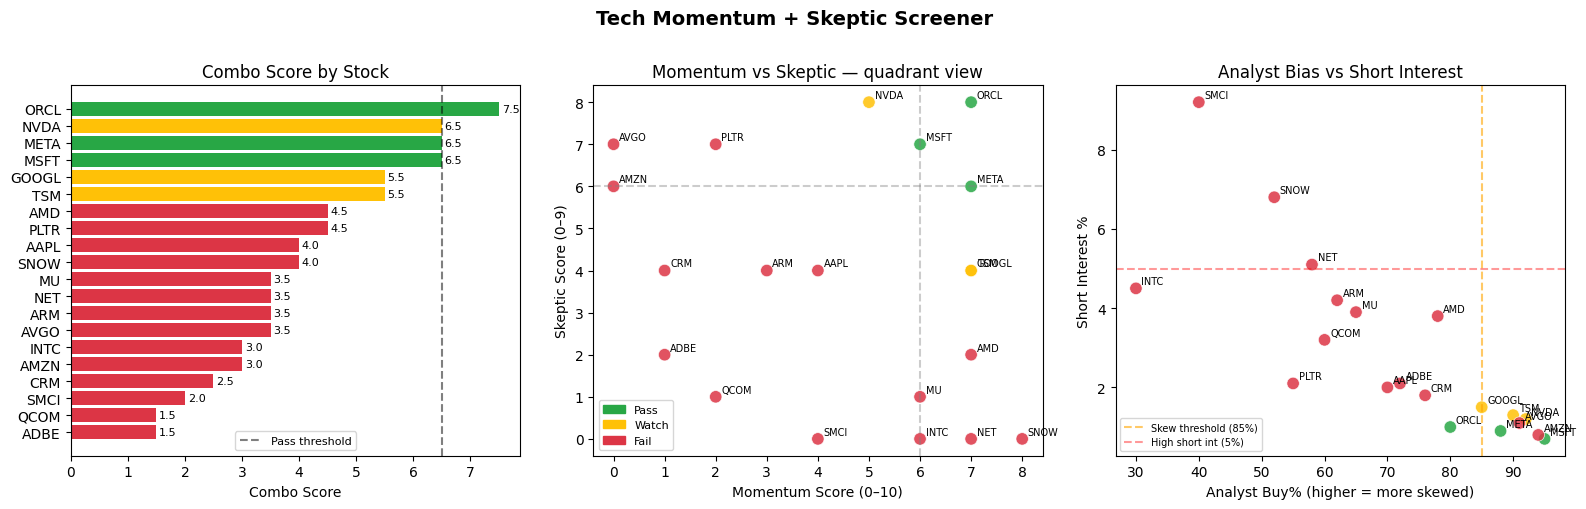

Charts saved to screener_charts.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Tech Momentum + Skeptic Screener", fontsize=14, fontweight="bold", y=1.01)

# ── Chart 1: Combo score bar
colors_map = {"Pass":"#28a745","Watch":"#ffc107","Fail":"#dc3545"}
bar_colors = [colors_map[v] for v in df["verdict"]]
axes[0].barh(df["symbol"], df["combo"], color=bar_colors)
axes[0].axvline(6.5, color="black", linestyle="--", alpha=0.5, label="Pass threshold")
axes[0].set_xlabel("Combo Score")
axes[0].set_title("Combo Score by Stock")
axes[0].invert_yaxis()
axes[0].legend(fontsize=8)
for i, (sym, val) in enumerate(zip(df["symbol"], df["combo"])):
    axes[0].text(val + 0.05, i, f"{val:.1f}", va="center", fontsize=8)

# ── Chart 2: Momentum vs Skeptic scatter
sc_colors = [colors_map[v] for v in df["verdict"]]
axes[1].scatter(df["mscore"], df["sscore"], c=sc_colors, s=80, alpha=0.85, edgecolors="white", linewidth=0.5)
for _, row in df.iterrows():
    axes[1].annotate(row["symbol"], (row["mscore"], row["sscore"]),
                     textcoords="offset points", xytext=(4, 3), fontsize=7)
axes[1].axvline(6, color="grey", linestyle="--", alpha=0.4)
axes[1].axhline(6, color="grey", linestyle="--", alpha=0.4)
axes[1].set_xlabel("Momentum Score (0–10)")
axes[1].set_ylabel("Skeptic Score (0–9)")
axes[1].set_title("Momentum vs Skeptic — quadrant view")
patches = [mpatches.Patch(color=c, label=l) for l, c in colors_map.items()]
axes[1].legend(handles=patches, fontsize=8)

# ── Chart 3: Analyst buy% vs short interest
df_plot = df.copy()
sc2 = axes[2].scatter(df_plot["analyst_buy_pct"], df_plot["short_interest"],
                      c=[colors_map[v] for v in df_plot["verdict"]],
                      s=80, alpha=0.85, edgecolors="white", linewidth=0.5)
for _, row in df_plot.iterrows():
    axes[2].annotate(row["symbol"], (row["analyst_buy_pct"], row["short_interest"]),
                     textcoords="offset points", xytext=(4, 3), fontsize=7)
axes[2].axvline(85, color="orange", linestyle="--", alpha=0.6, label="Skew threshold (85%)")
axes[2].axhline(5,  color="red",    linestyle="--", alpha=0.4, label="High short int (5%)")
axes[2].set_xlabel("Analyst Buy% (higher = more skewed)")
axes[2].set_ylabel("Short Interest %")
axes[2].set_title("Analyst Bias vs Short Interest")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig("screener_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts saved to screener_charts.png")

## 11. Export to CSV

In [ ]:
ts      = datetime.now().strftime("%Y%m%d_%H%M")
outpath = f"screen_results_{ts}.csv"

df_export = df.copy()
for col in ["ret_1w", "ret_1m", "ret_3m"]:
    df_export[col] = (df_export[col] * 100).round(2).astype(str) + "%"

df_export.to_csv(outpath, index=False)
print(f"✅ Saved {len(df_export)} rows → {outpath}")
display(df_export[["symbol","combo","verdict","mscore","sscore","ret_1m"]].head(10))

## 12. Optional — place orders for top picks via Schwab API

> ⚠️ **Only runs in LIVE mode** with valid Schwab credentials. Always review before submitting.


In [ ]:
# Only executes in live mode — safe to run in demo (will skip)
if not DEMO_MODE:
    from schwab.auth import easy_client
    from schwab.orders.equities import equity_buy_limit

    client  = easy_client(api_key=API_KEY, app_secret=APP_SECRET,
                          callback_url="https://127.0.0.1", token_path=TOKEN_PATH)
    resp    = client.get_account_numbers()
    acct    = resp.json()[0]["hashValue"]

    top_picks = df[df["verdict"] == "Pass"].head(3)

    for _, row in top_picks.iterrows():
        sym   = row["symbol"]
        price = row["price"]
        limit = round(price * 1.005, 2)   # 0.5% above last price
        qty   = 1                          # ← adjust quantity here

        print(f"  Submitting limit buy: {sym}  qty={qty}  limit=${limit}")
        # Uncomment to actually submit:
        # client.place_order(acct, equity_buy_limit(sym, qty, limit))
        print(f"  [Simulated — uncomment place_order() to go live]")
else:
    print("Skipped — running in DEMO mode. Set SCHWAB_API_KEY to enable live orders.")